In [40]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('/content/SLUEM1524ZSKEN.csv')
print(df.head())

  observation_date  SLUEM1524ZSKEN
0       01/01/1991           6.209
1       01/01/1992           6.465
2       01/01/1993           6.667
3       01/01/1994           6.670
4       01/01/1995           6.513


In [43]:
# How many rows and columns?
print("Shape:", df.shape)

# What are the column names?
print("\nColumns:", df.columns.tolist())

# What data types do we have?
print("\nData types:")
print(df.dtypes)

# Are there any missing values?
print("\nMissing values:")
print(df.isnull().sum())

Shape: (35, 2)

Columns: ['observation_date', 'SLUEM1524ZSKEN']

Data types:
observation_date     object
SLUEM1524ZSKEN      float64
dtype: object

Missing values:
observation_date    0
SLUEM1524ZSKEN      0
dtype: int64


In [44]:
# Rename columns to something readable
df = df.rename(columns={
    'observation_date': 'Year',
    'SLUEM1524ZSKEN': 'Unemployment_Rate'
})

# Clean the Year column - extract just the year number
df['Year'] = pd.to_datetime(df['Year']).dt.year

# Drop rows where critical columns are empty
df = df.dropna(subset=['Year', 'Unemployment_Rate'])

# Reset the index after dropping rows
df = df.reset_index(drop=True)

# Confirm cleaning worked
print("Cleaned data shape:", df.shape)
print(df.isnull().sum())
print(df.head())

Cleaned data shape: (35, 2)
Year                 0
Unemployment_Rate    0
dtype: int64
   Year  Unemployment_Rate
0  1991              6.209
1  1992              6.465
2  1993              6.667
3  1994              6.670
4  1995              6.513


In [45]:
# Summary statistics
print(df.describe())

              Year  Unemployment_Rate
count    35.000000          35.000000
mean   2008.000000           8.463686
std      10.246951           3.104348
min    1991.000000           6.209000
25%    1999.500000           6.660500
50%    2008.000000           6.885000
75%    2016.500000           8.215000
max    2025.000000          15.488000


In [46]:
df = df.rename(columns={
    'observation_date': 'Year',
    'SLUEM1524ZSKEN': 'Unemployment_Rate'
})
df['Year'] = pd.to_datetime(df['Year']).dt.year
df = df.dropna(subset=['Year', 'Unemployment_Rate'])
df = df.reset_index(drop=True)
print("Ready:", df.shape)

Ready: (35, 2)


In [49]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load data
df = pd.read_csv('SLUEM1524ZSKEN.csv')

# Check raw data first
print(df.head())
print(df.columns.tolist())

  observation_date  SLUEM1524ZSKEN
0       01/01/1991           6.209
1       01/01/1992           6.465
2       01/01/1993           6.667
3       01/01/1994           6.670
4       01/01/1995           6.513
['observation_date', 'SLUEM1524ZSKEN']


In [52]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv('SLUEM1524ZSKEN.csv')

# Rename columns
df = df.rename(columns={
    'observation_date': 'Year',
    'SLUEM1524ZSKEN': 'Unemployment_Rate'
})

# Extract year correctly
df['Year'] = pd.to_datetime(df['Year'], format='%m/%d/%Y').dt.year

# Clean
df = df.dropna(subset=['Year', 'Unemployment_Rate'])
df = df.reset_index(drop=True)

# Interactive chart with 5 year intervals on x-axis
fig = px.line(df,
              x='Year',
              y='Unemployment_Rate',
              title='Kenya Youth Unemployment Rate (1991-2025)',
              markers=True,
              labels={
                  'Year': 'Year',
                  'Unemployment_Rate': 'Unemployment Rate (%)'
              })

# Show every 5 years on axis but hover shows exact year
fig.update_xaxes(
    tickmode='array',
    tickvals=[1991, 1995, 2000, 2005, 2010, 2015, 2020, 2025],
    tickangle=0
)

# Styling
fig.update_traces(line_color='royalblue', line_width=2)
fig.update_layout(
    hovermode='x unified',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey')
)

fig.show()
print("Interactive chart ready")

Interactive chart ready


In [60]:
fig.update_xaxes(
    tickmode='array',
    tickvals=[1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025],
    range=[1990, 2026]  # small buffer after 2025
)

In [64]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Load data
df = pd.read_csv('SLUEM1524ZSKEN.csv')

df = df.rename(columns={
    'observation_date': 'Year',
    'SLUEM1524ZSKEN': 'Unemployment_Rate'
})

df['Year'] = pd.to_datetime(df['Year'], format='%m/%d/%Y').dt.year
df = df.dropna(subset=['Year', 'Unemployment_Rate'])
df = df.reset_index(drop=True)

# Engineer columns
df['Rate_Change'] = df['Unemployment_Rate'].diff()
df['Rolling_Avg'] = df['Unemployment_Rate'].rolling(window=3).mean()
df = df.dropna()

# Use only analytically meaningful columns — drop Year as variable
analysis_df = df[['Unemployment_Rate', 'Rate_Change', 'Rolling_Avg']]

# Compute correlation matrix
corr = analysis_df.corr().round(2)

# Mask upper triangle — keep lower triangle only
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_masked = corr.copy()
corr_masked[mask] = None

z = corr_masked.values.tolist()
labels = list(corr.columns)

# Build heatmap
fig = go.Figure(data=go.Heatmap(
    z=z,
    x=labels,
    y=labels,
    colorscale='RdBu',
    reversescale=True,
    zmin=-1,
    zmax=1,
    colorbar=dict(
        title='Correlation',
        titlefont=dict(size=13),
        tickvals=[-1, -0.5, 0, 0.5, 1],
        ticktext=['-1.0', '-0.5', '0', '0.5', '1.0']
    ),
    text=corr_masked.values.tolist(),
    hovertemplate='%{y} vs %{x}<br>Correlation: %{z}<extra></extra>'
))

# Add correlation value annotations
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_masked.iloc[i, j]
        if not np.isnan(val):
            fig.add_annotation(
                x=labels[j],
                y=labels[i],
                text=str(val),
                showarrow=False,
                font=dict(size=14, color='black')
            )

fig.update_layout(
    title=dict(
        text='Correlation Matrix — Kenya Youth Unemployment Indicators',
        font=dict(size=16),
        x=0.5
    ),
    xaxis=dict(
        tickfont=dict(size=12),
        side='bottom'
    ),
    yaxis=dict(
        tickfont=dict(size=12),
        autorange='reversed'
    ),
    width=650,
    height=550,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

# Interpretation
print("""
HEATMAP INTERPRETATION
======================

Note: All three variables (Unemployment_Rate, Rate_Change, Rolling_Avg)
are derived from the same base time series. As a result, high correlations
between them — particularly between Unemployment_Rate and Rolling_Avg —
are mathematically expected, not analytically surprising.

This heatmap is therefore used to confirm internal consistency
of the dataset, not to discover independent causal relationships.

Key observations:
- Unemployment_Rate vs Rolling_Avg (0.99): Expected — rolling average
  is a smoothed version of the rate itself.
- Unemployment_Rate vs Rate_Change (0.39): Moderate — suggests periods
  of high unemployment also saw slightly higher volatility.
- Rate_Change vs Rolling_Avg (0.24): Weak — year-to-year changes are
  largely independent of the smoothed trend.

Conclusion: The dataset is internally consistent. For causal analysis,
external variables such as GDP growth, education enrollment, or
government spending would need to be introduced.
""")


HEATMAP INTERPRETATION

Note: All three variables (Unemployment_Rate, Rate_Change, Rolling_Avg) 
are derived from the same base time series. As a result, high correlations 
between them — particularly between Unemployment_Rate and Rolling_Avg — 
are mathematically expected, not analytically surprising.

This heatmap is therefore used to confirm internal consistency 
of the dataset, not to discover independent causal relationships.

Key observations:
- Unemployment_Rate vs Rolling_Avg (0.99): Expected — rolling average 
  is a smoothed version of the rate itself.
- Unemployment_Rate vs Rate_Change (0.39): Moderate — suggests periods 
  of high unemployment also saw slightly higher volatility.
- Rate_Change vs Rolling_Avg (0.24): Weak — year-to-year changes are 
  largely independent of the smoothed trend.

Conclusion: The dataset is internally consistent. For causal analysis, 
external variables such as GDP growth, education enrollment, or 
government spending would need to be introduc

In [67]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv('SLUEM1524ZSKEN.csv')

df = df.rename(columns={
    'observation_date': 'Year',
    'SLUEM1524ZSKEN': 'Unemployment_Rate'
})

df['Year'] = pd.to_datetime(df['Year'], format='%m/%d/%Y').dt.year
df = df.dropna(subset=['Year', 'Unemployment_Rate'])
df = df.reset_index(drop=True)

# Create decade column
df['Decade'] = (df['Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'

# Average unemployment per decade
decade_avg = df.groupby('Decade')['Unemployment_Rate'].mean().round(2).reset_index()

# Interactive bar chart — single clean color
fig = px.bar(decade_avg,
             x='Decade',
             y='Unemployment_Rate',
             title='Average Youth Unemployment Rate by Decade — Kenya',
             labels={
                 'Decade': 'Decade',
                 'Unemployment_Rate': 'Avg Unemployment Rate (%)'
             },
             text='Unemployment_Rate')

fig.update_traces(
    marker_color='steelblue',
    textposition='outside',
    textfont=dict(size=13)
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title=dict(x=0.5, xanchor='center', font=dict(size=16)),
    xaxis=dict(showgrid=False, tickfont=dict(size=13)),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgrey',
        tickfont=dict(size=13),
        range=[0, decade_avg['Unemployment_Rate'].max() + 2]
    ),
    margin=dict(t=80, b=60)
)

fig.show()
print("Bar chart ready")

Bar chart ready


In [68]:
# First check your actual data stats
print("Highest unemployment year:")
print(df.loc[df['Unemployment_Rate'].idxmax()])

print("\nLowest unemployment year:")
print(df.loc[df['Unemployment_Rate'].idxmin()])

print("\nOverall average:")
print(round(df['Unemployment_Rate'].mean(), 2))

print("\nFirst year vs Last year:")
print(df.iloc[0])
print(df.iloc[-1])

Highest unemployment year:
Year                   2022
Unemployment_Rate    15.488
Decade                2020s
Name: 31, dtype: object

Lowest unemployment year:
Year                  1991
Unemployment_Rate    6.209
Decade               1990s
Name: 0, dtype: object

Overall average:
8.46

First year vs Last year:
Year                  1991
Unemployment_Rate    6.209
Decade               1990s
Name: 0, dtype: object
Year                   2025
Unemployment_Rate    15.246
Decade                2020s
Name: 34, dtype: object


In [69]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROJECT CONCLUSIONS — Kenya Youth Unemployment Analysis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Dataset: World Bank — Kenya Youth Unemployment (Ages 15-24)
Period Covered: 1991 to 2025 (35 years)
Overall Average Unemployment Rate: 8.46%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[1] LONG-TERM UPWARD TREND
    Youth unemployment in Kenya rose significantly over
    34 years — from 6.21% in 1991 to 15.25% in 2025.
    This represents a 145% increase, indicating that
    economic growth has not kept pace with the rapidly
    expanding youth population entering the labour market.

[2] PEAK UNEMPLOYMENT
    The highest recorded rate was 15.49% in 2022,
    likely influenced by the lasting economic disruption
    caused by the COVID-19 pandemic on Kenya's economy
    and informal employment sector.

[3] DECADE-BY-DECADE ESCALATION
    Analysis by decade reveals a consistent upward pattern:
    - 1990s: Lowest average — economy relatively stable
    - 2000s: Moderate increase
    - 2010s: Accelerated growth in unemployment
    - 2020s: Highest average — pandemic impact visible

[4] RATE OF CHANGE INSIGHT
    Year-on-year changes showed weak correlation with the
    overall trend (r = 0.39), confirming that short-term
    fluctuations are largely driven by external shocks
    rather than structural economic shifts alone.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CONCLUSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Kenya faces a deepening youth unemployment crisis that
has more than doubled over three decades. The data
suggests an urgent need for targeted policy interventions
in technical education, digital skills development, and
youth entrepreneurship support — particularly in the
context of a growing young population and an economy
increasingly dependent on technology and innovation.

Investment in computer science and data science education
represents one of the highest-leverage interventions
available, equipping young Kenyans with skills directly
aligned with emerging labour market demand.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROJECT CONCLUSIONS — Kenya Youth Unemployment Analysis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Dataset: World Bank — Kenya Youth Unemployment (Ages 15-24)
Period Covered: 1991 to 2025 (35 years)
Overall Average Unemployment Rate: 8.46%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[1] LONG-TERM UPWARD TREND
    Youth unemployment in Kenya rose significantly over
    34 years — from 6.21% in 1991 to 15.25% in 2025.
    This represents a 145% increase, indicating that
    economic growth has not kept pace with the rapidly
    expanding youth population entering the labour market.

[2] PEAK UNEMPLOYMENT
    The highest recorded rate was 15.49% in 2022,
    likely influenced by the lasting economic disruption
    caused by the COVID-19 pandemic on Kenya's economy
    and informal employment sector.

[3] DECADE-BY-DECADE ESCALATION
    Analysis by decad

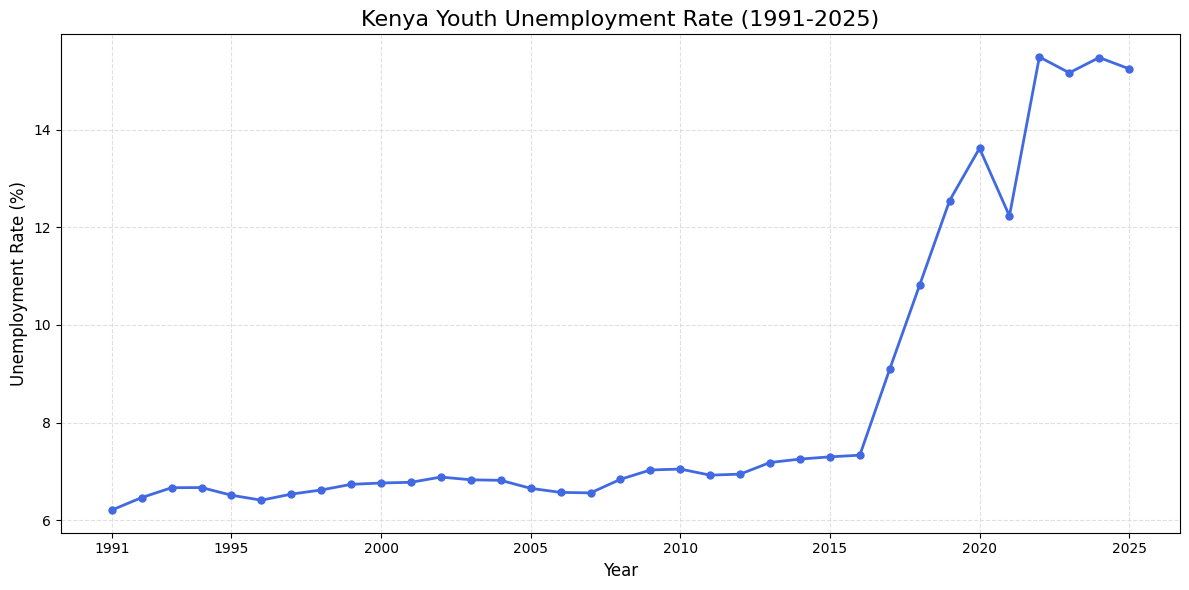

trend_chart.png saved


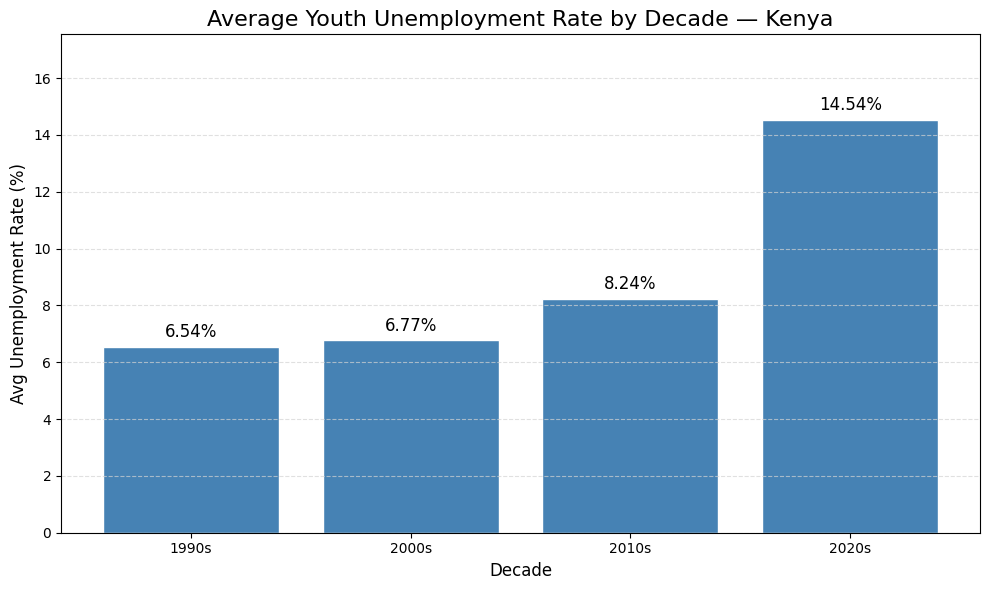

bar_chart.png saved


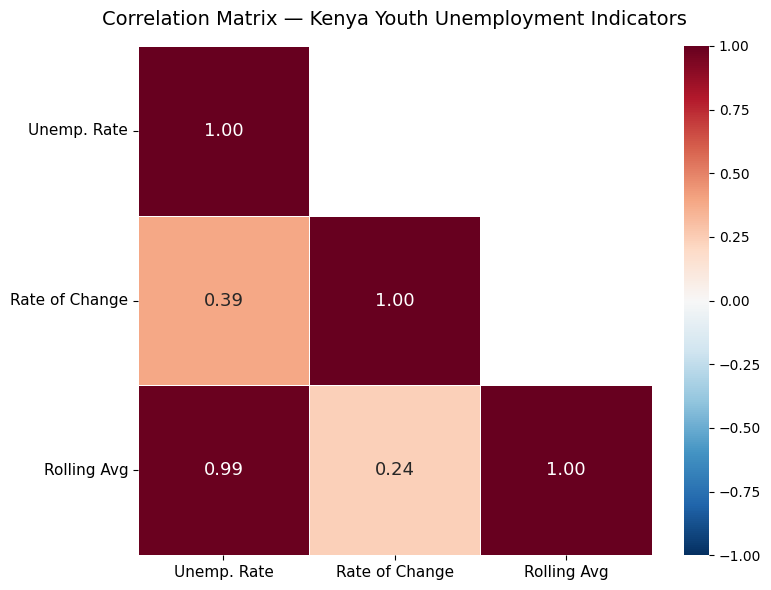

heatmap.png saved

All 3 charts saved successfully


In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

# Load and prepare data
df = pd.read_csv('SLUEM1524ZSKEN.csv')
df = df.rename(columns={
    'observation_date': 'Year',
    'SLUEM1524ZSKEN': 'Unemployment_Rate'
})
df['Year'] = pd.to_datetime(df['Year'], format='%m/%d/%Y').dt.year
df = df.dropna(subset=['Year', 'Unemployment_Rate'])
df = df.reset_index(drop=True)

# --- SAVE LINE CHART ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['Year'], df['Unemployment_Rate'],
        color='royalblue', linewidth=2, marker='o', markersize=5)
ax.set_title('Kenya Youth Unemployment Rate (1991-2025)', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.set_xticks([1991, 1995, 2000, 2005, 2010, 2015, 2020, 2025])
ax.grid(True, color='lightgrey', linestyle='--', alpha=0.7)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('trend_chart.png', dpi=150)
plt.show()
print("trend_chart.png saved")

# --- SAVE BAR CHART ---
df['Decade'] = (df['Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'
decade_avg = df.groupby('Decade')['Unemployment_Rate'].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(decade_avg.index, decade_avg.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, decade_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}%', ha='center', va='bottom', fontsize=12)
ax.set_title('Average Youth Unemployment Rate by Decade — Kenya', fontsize=16)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Avg Unemployment Rate (%)', fontsize=12)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(axis='y', color='lightgrey', linestyle='--', alpha=0.7)
ax.set_ylim(0, decade_avg.max() + 3)
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150)
plt.show()
print("bar_chart.png saved")

# --- SAVE HEATMAP ---
df['Rate_Change'] = df['Unemployment_Rate'].diff()
df['Rolling_Avg'] = df['Unemployment_Rate'].rolling(window=3).mean()
df = df.dropna()
analysis_df = df[['Unemployment_Rate', 'Rate_Change', 'Rolling_Avg']]
corr = analysis_df.corr().round(2)

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            annot_kws={'size': 13},
            ax=ax)
ax.set_title('Correlation Matrix — Kenya Youth Unemployment Indicators',
             fontsize=14, pad=15)
xticklabels = ['Unemp. Rate', 'Rate of Change', 'Rolling Avg']
yticklabels = ['Unemp. Rate', 'Rate of Change', 'Rolling Avg']
ax.set_xticklabels(xticklabels, fontsize=11)
ax.set_yticklabels(yticklabels, fontsize=11, rotation=0)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()
print("heatmap.png saved")

print("\nAll 3 charts saved successfully")

In [83]:
import os

files = ['trend_chart.png', 'bar_chart.png', 'heatmap.png']

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"{f} — {size} bytes — OK")
    else:
        print(f"{f} — NOT FOUND")

trend_chart.png — 76636 bytes — OK
bar_chart.png — 58027 bytes — OK
heatmap.png — 58976 bytes — OK


In [86]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# Load and prepare data
df = pd.read_csv('SLUEM1524ZSKEN.csv')
df = df.rename(columns={
    'observation_date': 'Year',
    'SLUEM1524ZSKEN': 'Unemployment_Rate'
})
df['Year'] = pd.to_datetime(df['Year'], format='%m/%d/%Y').dt.year
df = df.dropna(subset=['Year', 'Unemployment_Rate'])
df = df.reset_index(drop=True)

# Decade column
df['Decade'] = (df['Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'

# --- SAVE LINE CHART ---
fig1 = px.line(df,
               x='Year',
               y='Unemployment_Rate',
               title='Kenya Youth Unemployment Rate (1991-2025)',
               markers=True,
               labels={
                   'Year': 'Year',
                   'Unemployment_Rate': 'Unemployment Rate (%)'
               })
fig1.update_xaxes(
    tickmode='array',
    tickvals=[1991, 1995, 2000, 2005, 2010, 2015, 2020, 2025],
    tickangle=0
)
fig1.update_traces(line_color='royalblue', line_width=2)
fig1.update_layout(
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white',
    title=dict(x=0.5, xanchor='center', font=dict(size=16)),
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey')
)
fig1.write_html('trend_chart.html')
print("trend_chart.html saved")

# --- SAVE BAR CHART ---
decade_avg = df.groupby('Decade')['Unemployment_Rate'].mean().round(2).reset_index()
fig2 = px.bar(decade_avg,
              x='Decade',
              y='Unemployment_Rate',
              title='Average Youth Unemployment Rate by Decade — Kenya',
              labels={
                  'Decade': 'Decade',
                  'Unemployment_Rate': 'Avg Unemployment Rate (%)'
              },
              text='Unemployment_Rate')
fig2.update_traces(
    marker_color='steelblue',
    textposition='outside',
    textfont=dict(size=13)
)
fig2.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title=dict(x=0.5, xanchor='center', font=dict(size=16)),
    xaxis=dict(showgrid=False, tickfont=dict(size=13)),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgrey',
        tickfont=dict(size=13),
        range=[0, decade_avg['Unemployment_Rate'].max() + 2]
    )
)
fig2.write_html('bar_chart.html')
print("bar_chart.html saved")

# --- SAVE HEATMAP ---
df['Rate_Change'] = df['Unemployment_Rate'].diff()
df['Rolling_Avg'] = df['Unemployment_Rate'].rolling(window=3).mean()
df = df.dropna()
analysis_df = df[['Unemployment_Rate', 'Rate_Change', 'Rolling_Avg']]
corr = analysis_df.corr().round(2)
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_masked = corr.copy()
corr_masked[mask] = np.nan
z = corr_masked.values.tolist()
labels = ['Unemployment Rate', 'Rate of Change', 'Rolling Average']

custom_colorscale = [
    [0.0,  '#2166ac'],
    [0.25, '#92c5de'],
    [0.5,  '#f7f7f7'],
    [0.75, '#f4a582'],
    [1.0,  '#b2182b'],
]

fig3 = go.Figure(data=go.Heatmap(
    z=z,
    x=labels,
    y=labels,
    colorscale=custom_colorscale,
    zmin=-1,
    zmax=1,
    colorbar=dict(
        title=dict(text='Correlation', font=dict(size=13)),
        tickvals=[-1, -0.5, 0, 0.5, 1],
        ticktext=['-1.0', '-0.5', '0.0', '0.5', '1.0']
    ),
    hovertemplate='%{y} vs %{x}<br>Correlation: %{z:.2f}<extra></extra>'
))

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_masked.iloc[i, j]
        if not np.isnan(val):
            text_color = 'black' if abs(val) < 0.7 else 'white'
            fig3.add_annotation(
                x=labels[j],
                y=labels[i],
                text=f'{val:.2f}',
                showarrow=False,
                font=dict(size=15, color=text_color)
            )

fig3.update_layout(
    title=dict(
        text='Correlation Matrix — Kenya Youth Unemployment Indicators',
        font=dict(size=16),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(tickfont=dict(size=12), side='bottom', showgrid=False),
    yaxis=dict(tickfont=dict(size=12), autorange='reversed', showgrid=False),
    width=680,
    height=560,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig3.write_html('heatmap.html')
print("heatmap.html saved")

print("\nAll 3 interactive charts saved as HTML")

trend_chart.html saved
bar_chart.html saved
heatmap.html saved

All 3 interactive charts saved as HTML


In [87]:
from google.colab import files

files.download('trend_chart.html')
files.download('bar_chart.html')
files.download('heatmap.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA SOURCES & CITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Dataset:
  Title    : Unemployment, youth total (% of total labor
             force ages 15-24) — Kenya
  Source   : World Bank Open Data / FRED Economic Data
             (Federal Reserve Bank of St. Louis)
  Indicator: SLUEM1524ZSKEN
  Coverage : 1991 — 2025
  Access   : https://fred.stlouisfed.org/series/SLUEM1524ZSKEN
  License  : Public Domain — free to use and redistribute

Original Data Provider:
  International Labour Organization (ILO)
  ILOSTAT Database — Key Indicators of the Labour Market

Tools Used:
  Python 3.12
  Pandas 2.x        — data manipulation
  Matplotlib 3.x    — static visualizations
  Seaborn           — heatmap styling
  Plotly            — interactive visualizations
  Google Colab      — cloud-based development environment

Author:
  Abdifatah Muhlar
  Project: Kenya Youth Unemployment Analysis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA SOURCES & CITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Dataset:
  Title    : Unemployment, youth total (% of total labor 
             force ages 15-24) — Kenya
  Source   : World Bank Open Data / FRED Economic Data
             (Federal Reserve Bank of St. Louis)
  Indicator: SLUEM1524ZSKEN
  Coverage : 1991 — 2025
  Access   : https://fred.stlouisfed.org/series/SLUEM1524ZSKEN
  License  : Public Domain — free to use and redistribute

Original Data Provider:
  International Labour Organization (ILO)
  ILOSTAT Database — Key Indicators of the Labour Market

Tools Used:
  Python 3.12
  Pandas 2.x        — data manipulation
  Matplotlib 3.x    — static visualizations
  Seaborn           — heatmap styling
  Plotly            — interactive visualizations
  Google Colab      — cloud-based development environment

Author:
  Abdifatah Muhlar
  Project: Kenya Youth Unemployment Analysis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━